# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy


In [74]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import random
import os

In [75]:
IMAGE_WIDTH=32
IMAGE_HEIGHT=32
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 30

ROOT_PATH = "C:\\Users\\detla\\Downloads\\clasificador_paisajes\\"

TRAIN_PATH = ROOT_PATH+ 'seg_train/'
TEST_PATH = ROOT_PATH + 'seg_test/'


CATEGORIES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [76]:
def cargar_datos(ruta, categorias):
    datos = []
    etiquetas = []
    
    for categoria in categorias:
        path_categoria = os.path.join(ruta, categoria)
        # Listar archivos en la carpeta de la categoría
        for img_nombre in os.listdir(path_categoria):
            try:
                # Construir ruta completa
                img_path = os.path.join(path_categoria, img_nombre)
                
                # Cargar imagen y redimensionar a 32x32
                img = load_img(img_path, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
                
                # Convertir a array numpy
                img_array = img_to_array(img)
                
                # Normalizar aquí mismo (dividir por 255) para tener datos entre 0 y 1
                # Esto cubre el apartado 3 también, pero es buena práctica hacerlo al cargar
                img_array = img_array / 255.0
                
                datos.append(img_array)
                etiquetas.append(categoria)
            except Exception as e:
                print(f"Error cargando {img_nombre}: {e}")
                
    return np.array(datos), np.array(etiquetas)

print("Cargando datos de entrenamiento...")
X_train_raw, y_train_raw = cargar_datos(TRAIN_PATH, CATEGORIES)
print(f"Datos de entrenamiento cargados: {X_train_raw.shape}")

print("Cargando datos de test...")
X_test_raw, y_test_raw = cargar_datos(TEST_PATH, CATEGORIES)
print(f"Datos de test cargados: {X_test_raw.shape}")

Cargando datos de entrenamiento...
Datos de entrenamiento cargados: (14034, 32, 32, 3)
Cargando datos de test...
Datos de test cargados: (3000, 32, 32, 3)


## 2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.

Muestras del conjunto de entrenamiento:


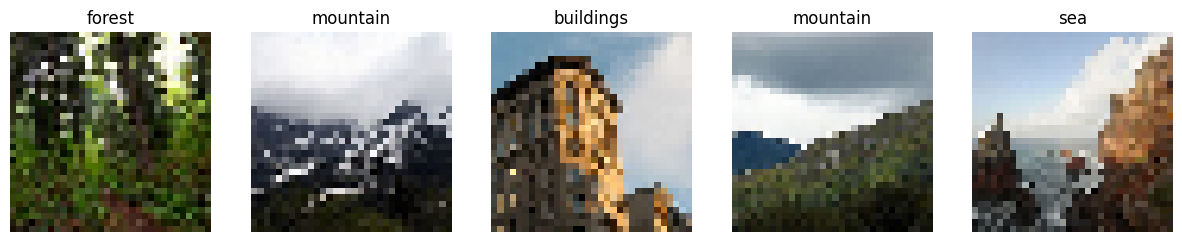

In [77]:
def mostrar_muestras(X, y, categorias, num_muestras=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_muestras):
        idx = random.randint(0, len(X) - 1)
        plt.subplot(1, num_muestras, i + 1)
        plt.imshow(X[idx])
        plt.title(y[idx])
        plt.axis('off')
    plt.show()

print("Muestras del conjunto de entrenamiento:")
mostrar_muestras(X_train_raw, y_train_raw, CATEGORIES)

## 3. Normaliza


In [78]:
X_train_raw = X_train_raw / 255.0
X_test_raw = X_test_raw / 255.0

print("Rango de valores píxel (debe ser 0 a 1):")
print(f"Min: {X_train_raw.min()}, Max: {X_train_raw.max()}")

Rango de valores píxel (debe ser 0 a 1):
Min: 0.0, Max: 0.003921568859368563


## 4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import cv2
from skimage.io import imread

from tensorflow import keras
from sklearn.metrics import confusion_matrix

In [80]:
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}
class_names_label

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [81]:
os.listdir(ROOT_PATH)

['seg_test', 'seg_train']

In [82]:
IMAGE_SIZE = (32,32)
TRAIN_PATH = ROOT_PATH + "/seg_train"
TEST_PATH = ROOT_PATH + "/seg_test"

In [83]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Asegúrate de tener definidas estas variables globales o ajustarlas a tu caso
# IMAGE_SIZE = (150, 150) 
# class_names_label = {'paisaje': 0, 'retrato': 1} # Ejemplo

def read_data(path, image_size):
    X = []
    y = []
    
    # Listamos todo lo que hay en la ruta
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        
        # CORRECCIÓN CLAVE: Verificamos que sea un DIRECTORIO y no un archivo suelto
        if not os.path.isdir(folder_path):
            continue
            
        # Verificamos que la carpeta sea una clase válida conocida
        if folder not in class_names_label:
            continue
            
        label = class_names_label[folder]
        
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            
            # Opcional: Ignorar archivos ocultos o no deseados dentro de las carpetas
            if file.startswith('.'):
                continue
                
            try:
                img = load_img(file_path, target_size=image_size)
                img_array = img_to_array(img)
                X.append(img_array)
                y.append(label)
            except Exception as e:
                print(f"Error cargando {file_path}: {e}")

    return np.array(X), np.array(y)

# Uso:
# X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE)
# X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE)

In [84]:
X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE)
X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14034, 32, 32, 3)
(3000, 32, 32, 3)
(14034,)
(3000,)


In [85]:
pd.Series(y_train).value_counts()

3    2512
2    2404
5    2382
4    2274
1    2271
0    2191
Name: count, dtype: int64

In [86]:
pd.Series(y_test).value_counts()

2    553
3    525
4    510
5    501
1    474
0    437
Name: count, dtype: int64

In [87]:
y_train[:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [88]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

In [89]:
y_train[:100]

array([0, 5, 5, 4, 3, 2, 3, 3, 0, 5, 0, 3, 5, 4, 2, 4, 4, 5, 1, 3, 2, 0,
       2, 2, 5, 1, 3, 5, 0, 3, 5, 5, 5, 2, 1, 2, 5, 4, 0, 1, 5, 1, 0, 4,
       0, 5, 1, 2, 3, 5, 4, 0, 2, 3, 5, 4, 0, 4, 1, 3, 3, 2, 4, 4, 2, 3,
       2, 1, 5, 3, 4, 1, 5, 1, 2, 1, 2, 1, 5, 3, 4, 5, 3, 1, 2, 3, 1, 4,
       4, 0, 3, 3, 4, 1, 5, 1, 5, 4, 1, 2])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


glacier


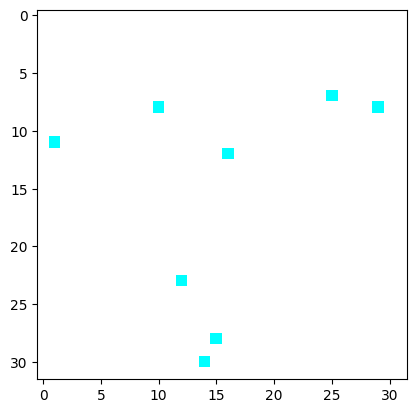

In [99]:
index = np.random.randint(X_train.shape[0])
print(class_names[y_train[index]])
plt.imshow(X_train[index]);

In [42]:
X_train

array([[[[227., 227., 227.],
         [222., 224., 223.],
         [223., 225., 224.],
         ...,
         [236., 236., 236.],
         [238., 238., 238.],
         [240., 240., 240.]],

        [[230., 230., 230.],
         [228., 228., 228.],
         [233., 233., 233.],
         ...,
         [244., 244., 244.],
         [244., 244., 244.],
         [247., 247., 247.]],

        [[ 27.,  27.,  27.],
         [252., 252., 252.],
         [ 91.,  91.,  91.],
         ...,
         [245., 245., 245.],
         [245., 245., 245.],
         [247., 247., 247.]],

        ...,

        [[101., 100.,  98.],
         [133., 132., 130.],
         [119., 117., 118.],
         ...,
         [ 86.,  85.,  83.],
         [ 77.,  76.,  74.],
         [ 87.,  86.,  84.]],

        [[128., 127., 125.],
         [ 45.,  44.,  42.],
         [133., 131., 132.],
         ...,
         [ 68.,  67.,  65.],
         [ 85.,  84.,  82.],
         [ 87.,  86.,  84.]],

        [[118., 117., 115.],
       

In [43]:
X_train[0][0][0][0]

np.float32(227.0)

In [44]:
print(X_train.min())
print(X_train.max())

0.0
255.0


In [45]:
X_train = X_train/255
X_test = X_test/255

In [46]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [47]:
X_train.shape

(14034, 32, 32, 3)

In [48]:
model = keras.Sequential([
    keras.layers.Conv2D(64, (3,3), input_shape=(32,32,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(32, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(6, activation="softmax")
])

c:\Users\detla\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,190 (371.84 KB)

 Trainable params: 95,190 (371.84 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [51]:
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.3801 - loss: 1.5048 - val_accuracy: 0.4464 - val_loss: 1.2785
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5733 - loss: 1.1134 - val_accuracy: 0.6074 - val_loss: 1.0174
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6354 - loss: 0.9660 - val_accuracy: 0.6641 - val_loss: 0.9072
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6803 - loss: 0.8581 - val_accuracy: 0.6833 - val_loss: 0.8677
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7082 - loss: 0.7965 - val_accuracy: 0.7104 - val_loss: 0.7935
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7241 - loss: 0.7458 - val_accuracy: 0.7047 - val_loss: 0.7992
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7492 - loss: 0.6931 - val_accuracy: 0.7157 - val_loss: 0.7680
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7612 - loss: 0.6635 - val_accuracy: 0.7193 - v

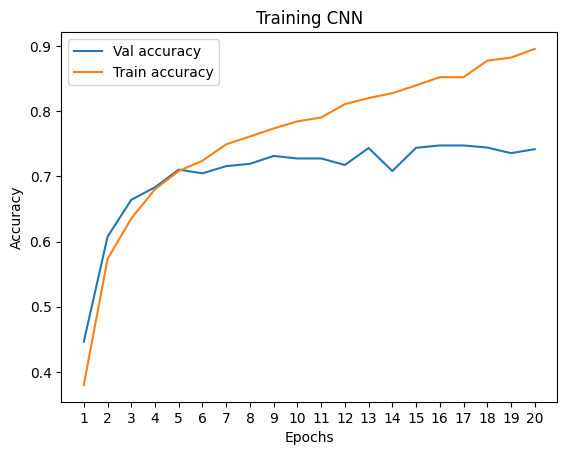

In [52]:
df_hist = pd.DataFrame(history.history, index=np.arange(1,21))
plt.plot(df_hist['val_accuracy'], label="Val accuracy")
plt.plot(df_hist['accuracy'], label="Train accuracy")
plt.title("Training CNN")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1,21))
plt.legend()

In [53]:
results = model.evaluate(X_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7403 - loss: 0.8235


In [54]:
y_pred = model.predict(X_test)
y_pred.round(2)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.  , 0.  , 0.19, 0.77, 0.03, 0.  ],
       [0.  , 0.01, 0.2 , 0.23, 0.02, 0.53],
       [0.  , 0.  , 0.03, 0.05, 0.92, 0.  ],
       ...,
       [0.  , 0.  , 0.37, 0.03, 0.6 , 0.  ],
       [0.  , 0.  , 0.02, 0.  , 0.98, 0.  ],
       [0.  , 0.99, 0.  , 0.  , 0.  , 0.  ]],
      shape=(3000, 6), dtype=float32)

In [55]:
IMAGE_SIZE = (64,64)

In [56]:
X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE)
X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14034, 64, 64, 3)
(3000, 64, 64, 3)
(14034,)
(3000,)


In [57]:
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)
X_train = X_train/255
X_test = X_test/255

In [58]:
print(X_train.shape)

(14034, 64, 64, 3)


In [59]:
model_2 = keras.Sequential([
    keras.layers.Conv2D(64, (3,3), input_shape=(64,64,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(6, activation="softmax")
])
model_2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])
history_2 = model_2.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5)]
)

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.5726 - loss: 1.1013 - val_accuracy: 0.6680 - val_loss: 0.8918
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - accuracy: 0.7014 - loss: 0.7977 - val_accuracy: 0.7107 - val_loss: 0.8019
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.7421 - loss: 0.7004 - val_accuracy: 0.7257 - val_loss: 0.7449
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - accuracy: 0.7832 - loss: 0.5931 - val_accuracy: 0.7410 - val_loss: 0.7177
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 0.8082 - loss: 0.5255 - val_accuracy: 0.7670 - val_loss: 0.6779
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 35s 200ms/step - accuracy: 0.8367 - loss: 0.4437 - val_accuracy: 0.7738 - val_loss: 0.6509
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - accuracy: 0.8622 - loss: 0.3788 - val_accuracy: 0.7766 - val_loss: 0.6802
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.8928 - loss: 0

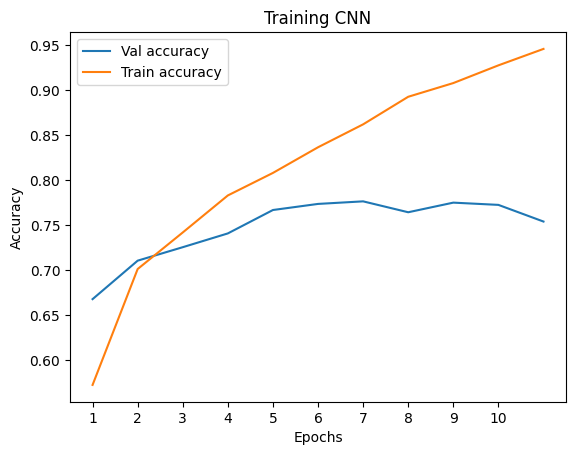

In [63]:
df_hist = pd.DataFrame(history_2.history, index=np.arange(1,12))
plt.plot(df_hist['val_accuracy'], label="Val accuracy")
plt.plot(df_hist['accuracy'], label="Train accuracy")
plt.title("Training CNN")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1,11))
plt.legend()

In [65]:
results = model_2.evaluate(X_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7473 - loss: 1.0497


In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Codificar etiquetas
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

# One-hot encoding para la capa de salida (softmax)
num_classes = len(CATEGORIES)
y_train_cat = to_categorical(y_train_encoded, num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes)

# Crear el modelo
model = Sequential([
    # Primera capa convolucional
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
    MaxPooling2D((2, 2)),
    
    # Segunda capa convolucional
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Capas Fully Connected
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Para evitar overfitting
    Dense(num_classes, activation='softmax') # Salida softmax para clasificación múltiple
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\detla\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,206 (1.20 MB)

 Trainable params: 315,206 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Reserva un 20% de los datos del entrenamiento para validar.


In [67]:
X_train, X_val, y_train, y_val = train_test_split(X_train_raw, y_train_cat, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Validación: {X_val.shape[0]} muestras")

Entrenamiento: 11227 muestras
Validación: 2807 muestras


In [68]:
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val, y_val))

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2979 - loss: 1.6431 - val_accuracy: 0.4314 - val_loss: 1.4295
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4390 - loss: 1.4341 - val_accuracy: 0.4738 - val_loss: 1.3587
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4661 - loss: 1.3717 - val_accuracy: 0.4913 - val_loss: 1.3184
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4835 - loss: 1.3418 - val_accuracy: 0.4945 - val_loss: 1.3082
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4985 - loss: 1.3138 - val_accuracy: 0.5077 - val_loss: 1.2691
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5008 - loss: 1.2988 - val_accuracy: 0.5208 - val_loss: 1.2262
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5179 - loss: 1.2654 - val_accuracy: 0.5394 - val_loss: 1.1929
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5212 - loss: 1.2523 - val_accuracy: 0.

## 6. Representa el objeto history


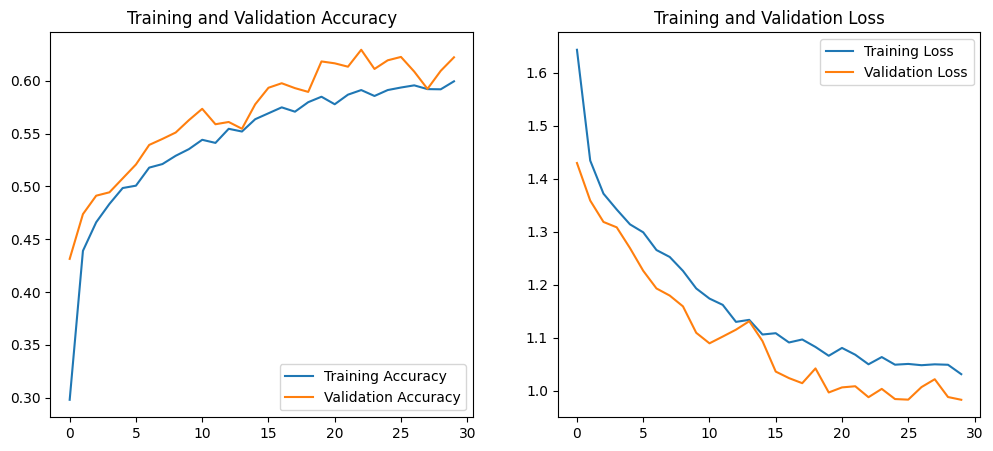

In [69]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    
    plt.show()

plot_history(history)

## 7. Evalua el modelo con los datos de test


In [70]:
test_loss, test_accuracy = model.evaluate(X_test_raw, y_test_cat)
print(f"Pérdida en Test: {test_loss:.4f}")
print(f"Precisión (Accuracy) en Test: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6190 - loss: 0.9760
Pérdida en Test: 0.9760
Precisión (Accuracy) en Test: 0.6190


## 8. Representa algunos de los paisajes donde el modelo comete errores


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


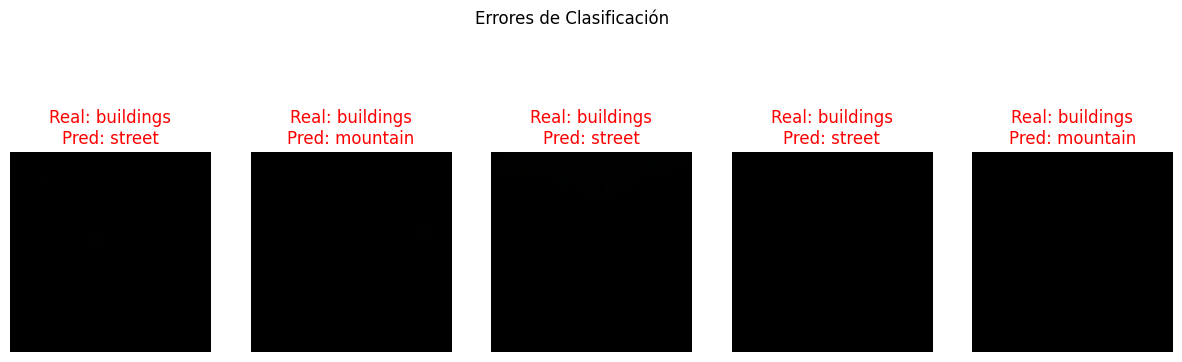

In [71]:
# Obtener predicciones
y_pred_probs = model.predict(X_test_raw)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Encontrar índices donde hubo error
errores_idx = np.where(y_pred_classes != y_true_classes)[0]

plt.figure(figsize=(15, 5))
# Mostrar hasta 5 errores
num_mostrar = min(5, len(errores_idx))
for i in range(num_mostrar):
    idx = errores_idx[i]
    plt.subplot(1, num_mostrar, i + 1)
    plt.imshow(X_test_raw[idx])
    true_label = CATEGORIES[y_true_classes[idx]]
    pred_label = CATEGORIES[y_pred_classes[idx]]
    plt.title(f"Real: {true_label}\nPred: {pred_label}", color='red' if true_label != pred_label else 'green')
    plt.axis('off')
plt.suptitle("Errores de Clasificación")
plt.show()

## 9. Crea una matriz de confusión con los errores del modelo


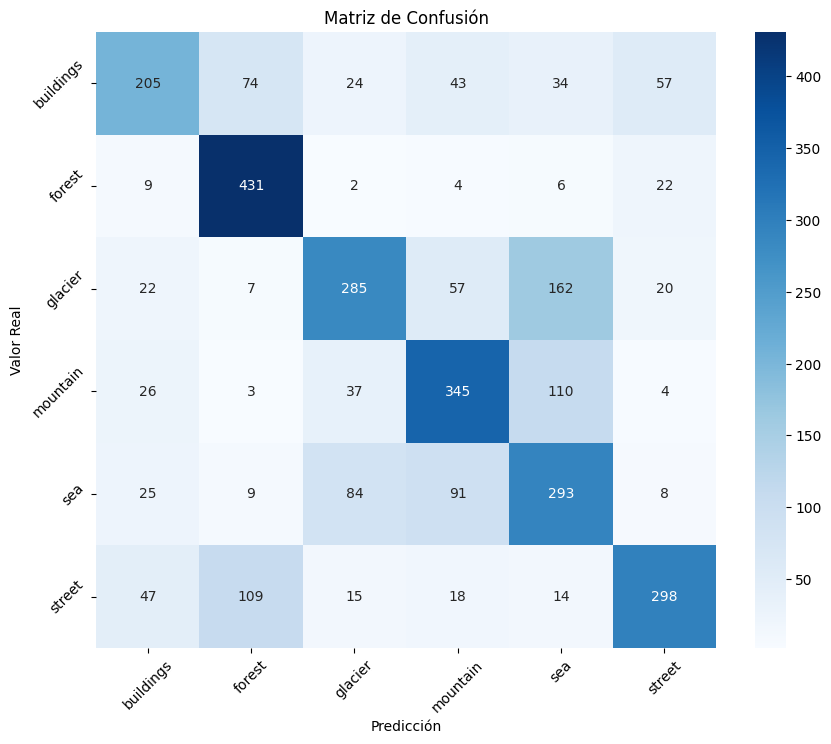

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()